In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv


# Step 1 — Problem Framing

# Telco Customer Churn — Business Problem Framing

## 1. Business Objective
Predict which customers are likely to churn (cancel their service) so that the retention team can proactively target them **within a real spending budget**.

---

## 2. Business Context

- A retention offer costs **₹500 per customer** (discount/voucher). We cannot send offers to every customer.
- The average lifetime value loss from a churned customer is **₹15,000**. Missing a real churner costs far more than the price of an offer.
- If we mistakenly offer a customer who was never going to churn, we only waste **₹500** — a small loss.
- Management's directive: *"Avoid missed churners (FN) as much as possible — their loss is much bigger. False Positives are affordable."*

**Budget — two conditions to evaluate:**
| Condition | Budget |
|---|---|
| A — No limit | ₹545,500 (covers cost-optimal threshold's full list) |
| B — Limited | ₹300,000 (capped) |

**Deliverables Expected:**
1. A model predicting churn probability
2. The right evaluation metric reflecting business cost (not accuracy)
3. An optimal threshold, justified — not default 0.5
4. Final report: customers flagged + expected cost-benefit, under both budget conditions

---

## 3. Cost Analysis

| Error Type | Meaning | Cost |
|---|---|---|
| False Negative (FN) | Real churner predicted as "No Churn" | ₹15,000 (lost customer) |
| False Positive (FP) | Non-churner predicted as "Churn" | ₹500 (wasted offer) |

**Conclusion:** FN is ~30x costlier than FP. Because of this asymmetry, Recall is prioritized — but the final threshold must be derived by minimizing total cost, not by picking a default or an arbitrary value.

---

## 4. Class Imbalance Handling

- Dataset is imbalanced (~73% non-churners) → **Accuracy is misleading, avoided**.
- Model quality tracked using **PR-AUC / F1-score**.
- Note: these metrics judge model quality — the actual **deployment threshold is decided separately, by cost**, not by PR-AUC/F1.

---

## 5. Baseline

```python
# Majority-class baseline: predict everyone as "No Churn"
baseline_accuracy = 0.73   # 73% non-churners
baseline_recall_churners = 0.0
```

This is the **minimum benchmark** any real model must beat.

# Step 2 — Get the Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/telco-customer-churn-dataset/Telco Customer Churn Dataset.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3 — Initial EDA (Before Splitting)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.drop(columns=['customerID'], inplace=True)

In [9]:
df['TotalCharges'].value_counts()

TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
130.15      1
3211.9      1
7843.55     1
2196.3      1
197.4       1
Name: count, Length: 6531, dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')

In [11]:
print(df['TotalCharges'].isnull().sum())

11


In [12]:
# Target distribution
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

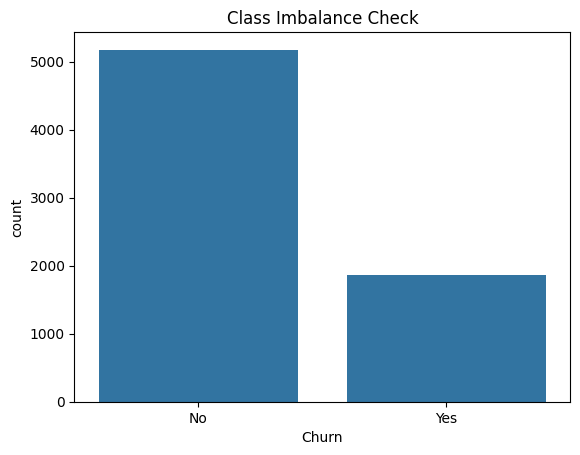

In [13]:
sns.countplot(x='Churn', data=df)
plt.title("Class Imbalance Check")
plt.show()

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

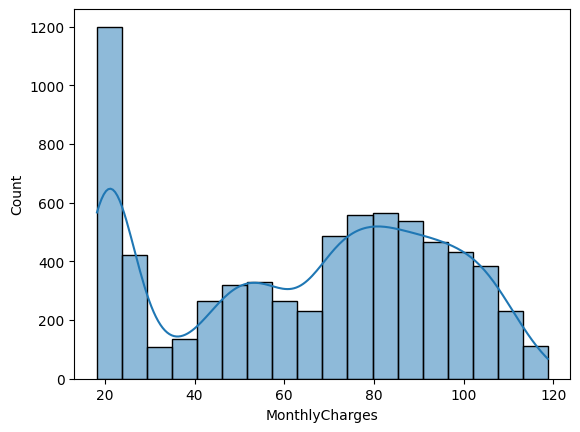

In [15]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

# Step 4 — Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [17]:
X_train.shape

(5634, 19)

In [18]:
X_test.shape

(1409, 19)

# Step 5 — Detailed EDA (Train Data Only)

In [19]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [20]:
X_train.shape

(5634, 19)

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [22]:
X_train['gender'].value_counts(dropna=False)

gender
Male      2833
Female    2801
Name: count, dtype: int64

In [23]:
X_train.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
dtype: int64

In [24]:
X_train.duplicated().sum()

np.int64(26)

In [25]:
dup_percent = (
    X_train.duplicated().sum()
    / len(X_train)
) * 100

print(f"Duplicate percentage: {dup_percent:.2f}%")

Duplicate percentage: 0.46%


In [26]:
duplicates = X_train[
    X_train.duplicated()
]

duplicates.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4789,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
1049,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65
1938,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.90,20.90
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45


In [27]:
X_train[
    X_train.duplicated(
        keep=False
    )
].sort_values(
    by=X_train.columns.tolist()
)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
684,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
4789,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
1736,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.50,19.50
4172,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.50,19.50


In [28]:
dup_idx = X_train[X_train.duplicated(keep=False)].index
y_train.loc[dup_idx].value_counts()

Churn
1    28
0    20
Name: count, dtype: int64

These aren't data-entry errors; they're different customers (different index/customerID) who genuinely happen to have the same profile (same tenure, plan, charges). With categorical features + tenure=1, coincidental matches are expected and realistic — that's real signal, not noise.

##### FInal decision is i will not remove them .

## Encoding Strategy Decision

In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [30]:
X_train.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [31]:
# i will apply one hot encoding on gender . (is_male = 0 or 1)

In [32]:
print(X_train['OnlineSecurity'].unique())

['No' 'Yes' 'No internet service']


In [33]:
# in the OnlineSecurity i will apply one hot encoding

In [34]:
# for the column Partner ,Dependents,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,
#   StreamingTV	,StreamingMovies,PaperlessBilling, Map them with yes and no with 1 and 0 . 

In [35]:
X_train['MultipleLines'].value_counts()

MultipleLines
No                  2685
Yes                 2390
No phone service     559
Name: count, dtype: int64

In [36]:
# i will apply one hot encoding in the MultipleLines column . 

In [37]:
X_train['InternetService'].value_counts()

InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64

In [38]:
# i will apply one hot encoding in the InternetService column . 

In [39]:
X_train['Contract'].value_counts()

Contract
Month-to-month    3102
Two year          1359
One year          1173
Name: count, dtype: int64

In [40]:
# in this Contract column i will apply ordinal encoding in this column . 

In [41]:
X_train['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             1891
Mailed check                 1286
Bank transfer (automatic)    1244
Credit card (automatic)      1213
Name: count, dtype: int64

In [42]:
# i will apply one hot encoding in this PaymentMethod column . 

## Missing Values Analysis

In [43]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

Totalcharges is float but it is showing object , check it and convert it into int . 

In [44]:
print(df['TotalCharges'].dtype)

float64


In [45]:
X_train['TotalCharges'].value_counts(dropna = False)

TotalCharges
20.20      9
NaN        8
19.65      7
45.30      7
20.05      6
          ..
4812.75    1
3068.60    1
3252.00    1
6697.35    1
414.10     1
Name: count, Length: 5276, dtype: int64

In [46]:
# at here there is no null values . 

In [47]:
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce') i will do this before train test split

In [48]:
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')

In [49]:
df['TotalCharges'].dtypes

dtype('float64')

In [50]:
print(df['TotalCharges'].isnull().sum())

11


In [51]:
# now lets find if the data is mcar , mar or mnar then i will conclude how to fill it . 

In [52]:
missing_mask = df['TotalCharges'].isnull()

df[missing_mask][['tenure', 'MonthlyCharges', 'Contract']]

,tenure,MonthlyCharges,Contract
488,0,52.55,Two year
753,0,20.25,Two year
936,0,80.85,Two year
1082,0,25.75,Two year
1340,0,56.05,Two year
3331,0,19.85,Two year
3826,0,25.35,Two year
4380,0,20.00,Two year
5218,0,19.70,One year
6670,0,73.35,Two year


In [53]:
print(df[missing_mask]['tenure'].unique())

[0]


Missing Value Analysis Note — TotalCharges Column

Finding:

The TotalCharges column had 11 missing values (originally stored as blank/space strings, which converted to NaN after pd.to_numeric()).



Investigation:

Checked the other observed columns (tenure, Contract) for the rows with missing TotalCharges.

Result: All 11 missing rows had tenure = 0, and most of them had long-term contracts (Two year or One year).



Interpretation:

These are new customers whose billing cycle hasn't started yet (tenure = 0 means less than a month with the company), so no total charge amount has been generated for them yet. The missingness is not random — it is explained by another observed variable (tenure), and reinforced by a second observed variable (Contract type of these customers).
Classification: MAR (Missing At Random)
The missingness of TotalCharges does not depend on its own unseen value; it depends on other observed columns in the dataset (tenure, and to some extent Contract). This rules out MNAR (which would require the missingness to depend on the value of TotalCharges itself) and MCAR (which would require no relationship with any other variable at 
all).



Imputation decision:

Since domain logic explains the missingness (tenure = 0 → no bill generated yet), the most appropriate fix is to set TotalCharges = 0 for these rows, rather than using 

median/mean imputation, since a new customer's total charge is genuinely 0, not "unknown."


### The conclusion is this missing value is completely missing at random MAR

In [54]:
# this means for the new customer , no bills were made . 

In [55]:
X_train['TotalCharges'].skew()

np.float64(0.9475162595460518)

#### Decision - I will fill it with zero 

Missing TotalCharges values all belong to customers with tenure = 0 (new customers, no bill generated yet). So the true value is actually 0, not an unknown number to estimate. Median/mean imputation is for unknown-but-real values — doesn't apply here since we know the real value via domain logic. Hence, fill with 0, not median/mean.

## Outliers Detection

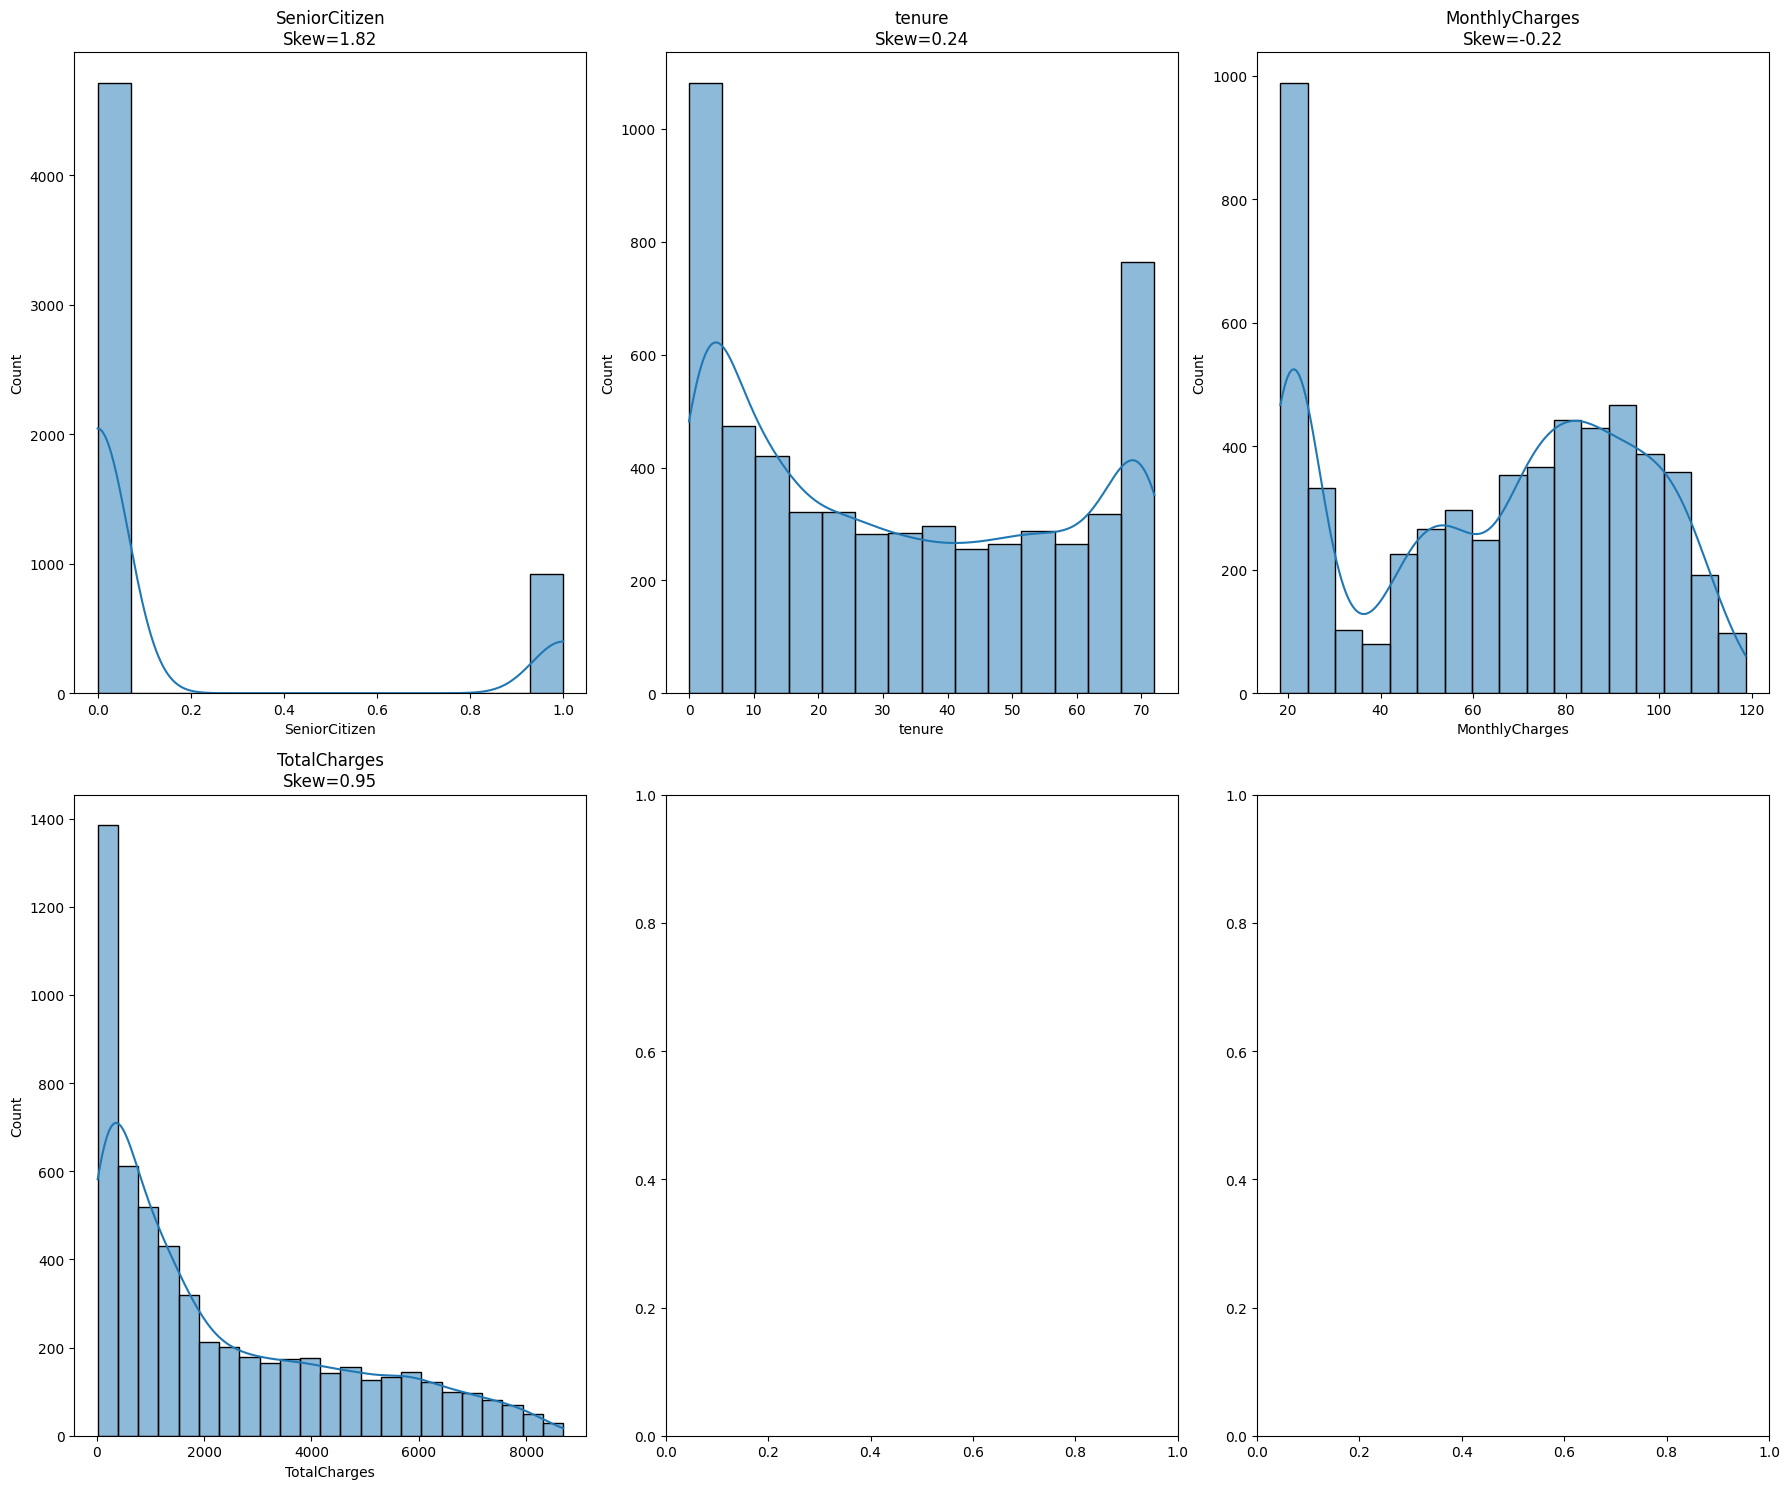

In [56]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+2)//3,
    ncols=3,
    figsize=(18,15)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[i]
    )

    skew = X_train[col].skew()

    axes[i].set_title(
        f'{col}\nSkew={skew:.2f}'
    )

plt.tight_layout()
plt.show()

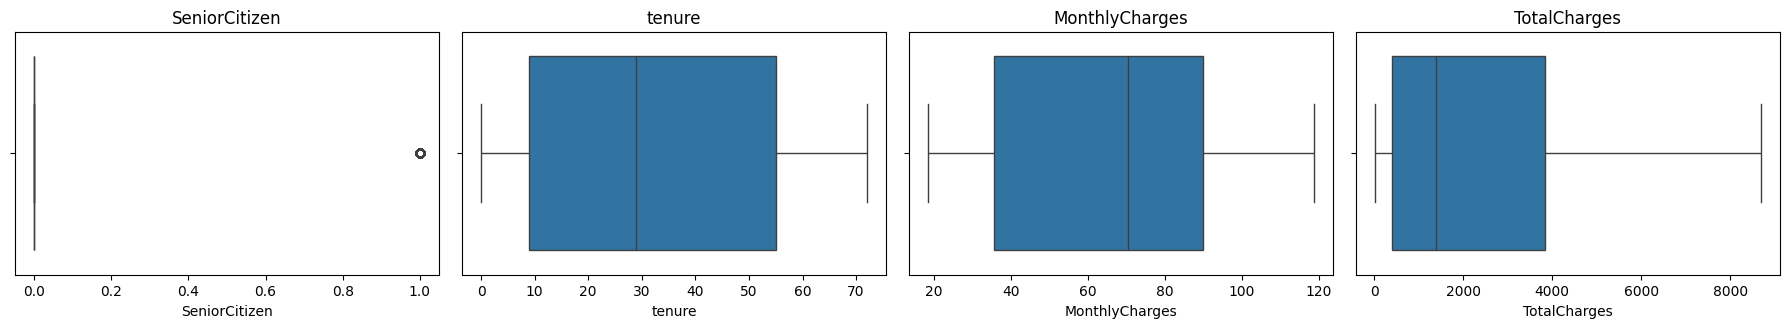

In [57]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(x=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [58]:
skewness = X_train[num_cols].skew()

highly_skewed = skewness[
    abs(skewness) > 0.5
].sort_values(ascending=False)

print(highly_skewed)

SeniorCitizen    1.822318
TotalCharges     0.947516
dtype: float64


In [59]:
X_train['SeniorCitizen'].describe()

count    5634.000000
mean        0.163294
std         0.369667
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

In [60]:
print(X_train['SeniorCitizen'].unique())

[0 1]


In [61]:
# 'SeniorCitizen' has only 0 and 1 , later i will convert it from one hot encoding 

In [62]:
X_train['TotalCharges'].describe()

count    5626.000000
mean     2302.604266
std      2279.173176
min        18.850000
25%       407.275000
50%      1398.125000
75%      3838.612500
max      8684.800000
Name: TotalCharges, dtype: float64

In [63]:
X_train['TotalCharges'].value_counts(dropna = False)

TotalCharges
20.20      9
NaN        8
19.65      7
45.30      7
20.05      6
          ..
4812.75    1
3068.60    1
3252.00    1
6697.35    1
414.10     1
Name: count, Length: 5276, dtype: int64

In [64]:
# since i have decided to fill it with 0 , and i want to use models like Random Forest, XGBoost , so skip the process of reducing its skewness . 

In [65]:
X_train.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55
2666,Male,0,No,Yes,66,Yes,No,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),79.50,5196.10
2645,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.80
189,Female,0,Yes,No,40,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.60,2379.10
5767,Female,0,Yes,No,65,Yes,No,DSL,No,No,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),59.80,3808.20
2257,Female,0,No,No,60,Yes,Yes,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05


# Step 6 — Preprocessing Pipeline

### Cleanup (Before Pipeline)

In [66]:
cols_with_redundant_no = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_with_redundant_no:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col] = X_test[col].replace('No internet service', 'No')

In [67]:
# replacing the No internet service with 'No'

## Column Groups Define

In [68]:
onehot_binary_col = ['gender']  


binary_cols = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', # columns having Yes and No
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


onehot_cols = ['MultipleLines', 'InternetService', 'PaymentMethod']

ordinal_col = ['Contract']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

passthrough_cols = ['SeniorCitizen']  

## Pipeline

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# 1. gender -> single 0/1 column
gender_transformer = OneHotEncoder(drop='if_binary')

# 2. Yes/No  binary columns -> OrdinalEncoder - 0/1
binary_transformer = OrdinalEncoder(
    categories=[['No', 'Yes']] * len(binary_cols),
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# 3. Multi-category nominal columns -> one-hot
onehot_transformer = OneHotEncoder(handle_unknown='ignore')

# 4. Contract -> ordinal (natural order)
ordinal_transformer = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])

# 5. Numeric -> only NaN fill , NO scaling for tree-based models.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])


In [70]:
preprocessor = ColumnTransformer(transformers=[
    ('gender', gender_transformer, onehot_binary_col),
    ('binary', binary_transformer, binary_cols),
    ('onehot', onehot_transformer, onehot_cols),
    ('ordinal', ordinal_transformer, ordinal_col),
    ('num', numeric_transformer, num_cols),
    ('passthrough', 'passthrough', passthrough_cols)
])

In [71]:
from sklearn import set_config
set_config(display='diagram')

preprocessor  

ColumnTransformer(transformers=[('gender', OneHotEncoder(drop='if_binary'),
                                 ['gender']),
                                ('binary',
                                 OrdinalEncoder(categories=[['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes'],
                                                            ['No', 'Yes']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['Partner', 'Dependents', 'PhoneService',
                                  'Onl...
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['MultipleLines', 'InternetService',
                                  'PaymentMethod']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['Month-to-month',
                                                             'One year',
                                                             'Two year']]),
                                 ['Contract']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'))]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('passthrough', 'passthrough',
                                 ['SeniorCitizen'])])

# Step 7 - Fit Preprocessing On Train Data Only

In [72]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [73]:
feature_names = preprocessor.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_transformed_df.head(10)

,gender__gender_Male,binary__Partner,binary__Dependents,binary__PhoneService,binary__OnlineSecurity,binary__OnlineBackup,binary__DeviceProtection,binary__TechSupport,binary__StreamingTV,binary__StreamingMovies,...,onehot__InternetService_No,onehot__PaymentMethod_Bank transfer (automatic),onehot__PaymentMethod_Credit card (automatic),onehot__PaymentMethod_Electronic check,onehot__PaymentMethod_Mailed check,ordinal__Contract,num__tenure,num__MonthlyCharges,num__TotalCharges,passthrough__SeniorCitizen
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,35.0,49.20,1701.65,0.0
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,15.0,75.10,1151.55,0.0
2,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,13.0,40.55,590.35,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2.0,26.0,73.50,1905.70,0.0
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.55,44.55,0.0
5,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2.0,66.0,79.50,5196.10,0.0
6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,19.80,19.80,0.0
7,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,40.0,56.60,2379.10,0.0
8,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2.0,65.0,59.80,3808.20,0.0
9,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,60.0,80.55,4847.05,0.0


since it is a Classification problem , focus on 

1. Accuracy, Precision, Recall, F1-score .
2. ROC-AUC, PR-AUC .
3. Log Loss (probability quality — how much confident and calibrated is the model)
4. Confusion Matrix (error breakdown)
5. Matthews Correlation Coefficient (MCC) —  A Realiable metric for imbalanced data . 

# Step 8 -  Model Training 

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Class imbalance ratio (churn ~27%) 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [75]:
# 1. Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('passthrough', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [76]:
# 2. XGBoost 
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [77]:
# 3. LightGBM 
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('gender',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Partner',...
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('passthrough', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('model',
                 LGBMClassifier(random_state=42,
                                scale_pos_weight=np.float64(2.768561872909699)))])

# Step 9 — Cross-Validation & Hyperparameter Tuning

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.3f}, std = {scores.std():.3f}, all folds = {np.round(scores,3)}")

Random Forest: mean F1 = 0.537, std = 0.026, all folds = [0.515 0.518 0.583 0.519 0.55 ]
XGBoost: mean F1 = 0.601, std = 0.018, all folds = [0.593 0.571 0.615 0.606 0.622]
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265306 -> initscore=-1.018570
[LightGBM] [Info] Start training from score -1.018570
LightGBM: mean F1 = 0.626, std = 0.009, all folds = [0.629 0.612 0.62  0.63  0.639]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📊 Model Performance Summary

| Model         | Mean F1 Score | Standard Deviation |
| ------------- | ------------: | -----------------: |
| Random Forest |         0.537 |              0.026 |
| XGBoost       |         0.601 |              0.018 |
| LightGBM      |     **0.626** |          **0.009** |


LightGBM wins — highest F1 and most least std (most stable across folds).
                                               
This model is selected for tunning. 

In [79]:
# LightGBM tuning (best CV model)
param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 5, 7, -1],          # -1 = no limit
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__num_leaves': [20, 31, 50, 70],
    'model__subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    lgbm_pipeline, param_dist, n_iter=20, cv=skf,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Step 10 — Error Analysis

In [80]:
# ROC Curve - Model Comparison

import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, roc_auc_score

colors = {'Random Forest': 'orange', 'XGBoost': 'green', 'LightGBM': 'blue', 'Tuned LightGBM': 'red'}
data = []

for name, model in pipelines.items():   # {'Random Forest': rf_pipeline, 'XGBoost': xgb_pipeline, 'LightGBM': lgbm_pipeline}
    y_prob_i = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_i)
    auc_val = roc_auc_score(y_test, y_prob_i)

    trace = go.Scatter(
        x=fpr,
        y=tpr,
        mode='lines',
        name=f'{name} (AUC = {auc_val:.3f})',
        line=dict(color=colors[name]),
        hovertemplate='FPR=%{x:.3f}<br>TPR=%{y:.3f}<extra>' + name + '</extra>'
    )
    data.append(trace)

    # Finding nearest point from (0,1) for best thresold . 
    distances = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
    best_idx = np.argmin(distances)
    best_fpr, best_tpr, best_thresh = fpr[best_idx], tpr[best_idx], thresholds[best_idx]

    marker_trace = go.Scatter(
        x=[best_fpr],
        y=[best_tpr],
        mode='markers',
        name=f'{name} Best Thr={best_thresh:.2f}',
        marker=dict(color=colors[name], size=12, symbol='star', line=dict(color='black', width=1)),
        hovertemplate=f'{name}<br>Best Threshold=%{{text:.2f}}<br>FPR=%{{x:.3f}}<br>TPR=%{{y:.3f}}<extra></extra>',
        text=[best_thresh]
    )
    data.append(marker_trace)

    print(f"{name}: Best Threshold = {best_thresh:.3f} (FPR={best_fpr:.3f}, TPR={best_tpr:.3f})")

# Diagonal line (random guess)
diagonal = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash', color='gray')
)
data.append(diagonal)

layout = go.Layout(
    title='ROC Curve - Model Comparison',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=1200,
    height=800,
    showlegend=True
)

fig = go.Figure(data=data, layout=layout)
fig.show()

Random Forest: Best Threshold = 0.236 (FPR=0.294, TPR=0.807)
XGBoost: Best Threshold = 0.322 (FPR=0.281, TPR=0.778)
LightGBM: Best Threshold = 0.447 (FPR=0.274, TPR=0.783)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Note — ROC Curve: Model Comparison

Purpose: Compare RF, XGBoost, LightGBM on threshold-independent discriminative ability to select base model.

Observation: All 3 models show similar TPR (~0.78–0.81); LightGBM has the lowest FPR (0.274) → slightly better separation.

Decision: LightGBM selected as base model.
    
Caveat: These "best thresholds" (0.236/0.322/0.447) assume equal FP/FN cost — used only for model comparison here,
         not the final deployment threshold (decided later via cost function).

In [81]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, average_precision_score

colors = {'Random Forest': 'orange', 'XGBoost': 'green', 'LightGBM': 'blue', 'Tuned LightGBM': 'red'}
data = []

for name, model in pipelines.items():
    y_prob_i = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob_i)
    pr_auc = average_precision_score(y_test, y_prob_i)

    trace = go.Scatter(
        x=recall, y=precision, mode='lines',
        name=f'{name} (PR-AUC = {pr_auc:.3f})',
        line=dict(color=colors[name])
    )
    data.append(trace)

baseline_line = go.Scatter(
    x=[0, 1], y=[y_test.mean(), y_test.mean()],
    mode='lines', name=f'Baseline = {y_test.mean():.3f}',
    line=dict(dash='dash', color='gray')
)
data.append(baseline_line)

layout = go.Layout(
    title='Precision-Recall Curve - Model Comparison',
    xaxis=dict(title='Recall'), yaxis=dict(title='Precision'),
    width=1200, height=800
)
fig = go.Figure(data=data, layout=layout)
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Note — Precision-Recall Curve: Model Comparison

Purpose: Confirm model choice using an imbalance-sensitive metric (PR-AUC), since dataset is ~73%-27% split.

Observation: LightGBM has the highest PR-AUC (0.650) vs XGBoost (0.624) and Random Forest (0.618); all three comfortably beat the baseline (0.265 = churn class ratio).

Decision: Confirms LightGBM as the base model — consistent with the ROC comparison.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



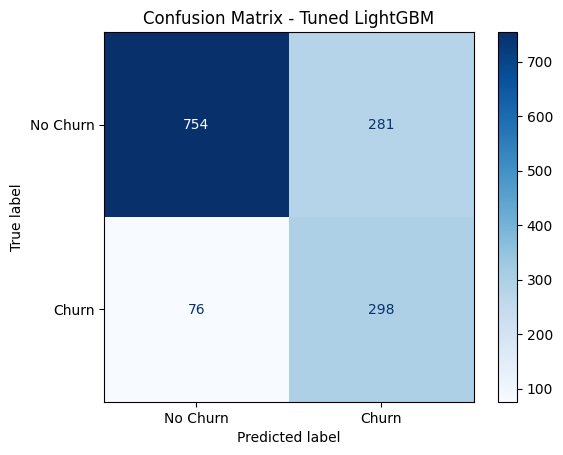

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [82]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned LightGBM")
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Note — Confusion Matrix: Tuned LightGBM (Default Threshold = 0.5)

Purpose: Diagnose chosen model's performance at the default threshold before any business-driven adjustment.

Observation: Recall for Churn is 0.80 (good — most churners caught), but Precision for Churn is only 0.51 (many false alarms). Overall accuracy (0.75) is misleading due to class imbalance.

Decision: Default threshold gives decent Recall but weak Precision — confirms need for threshold tuning based on actual business cost, not default 0.5.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



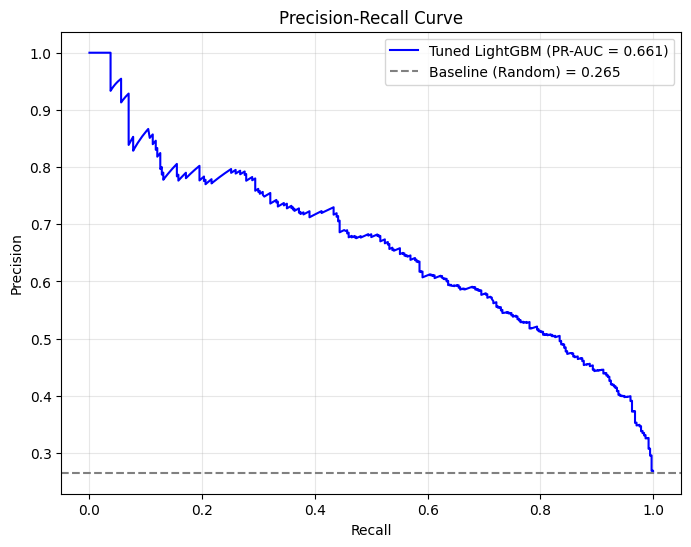

PR-AUC: 0.661
Baseline PR-AUC (positive class ratio): 0.265


In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate precision, recall at all thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

# PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_prob)

# Baseline = positive class ratio (random model's PR-AUC)
baseline = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Tuned LightGBM (PR-AUC = {pr_auc:.3f})')
plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline (Random) = {baseline:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"PR-AUC: {pr_auc:.3f}")
print(f"Baseline PR-AUC (positive class ratio): {baseline:.3f}")

Note — Precision-Recall Curve (Tuned LightGBM, Single Model)

Purpose: Deeper look at chosen model's precision-recall trade-off across all thresholds.

Observation: PR-AUC = 0.661, well above baseline (0.265) — confirms model has strong predictive power for the minority (Churn) class, independent of any specific threshold.
                                                                                                     
Decision: Model quality confirmed suitable for further threshold-based business decisions.

In [84]:
from sklearn.metrics import matthews_corrcoef

y_pred = best_model.predict(X_test)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"MCC: {mcc:.3f}")

MCC: 0.471


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Note — MCC at Default Threshold (0.5)

Purpose: Check a balanced metric that accounts for all four confusion matrix values (TP, TN, FP, FN) — more reliable than Accuracy on imbalanced data.
    
Observation: MCC = 0.471 — moderate positive correlation between predicted and actual labels; better than random (0) but leaves room for improvement.
                                                                                                                                    
Decision: Confirms model has genuine predictive skill beyond class imbalance, but default threshold isn't optimized — motivates threshold tuning next.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



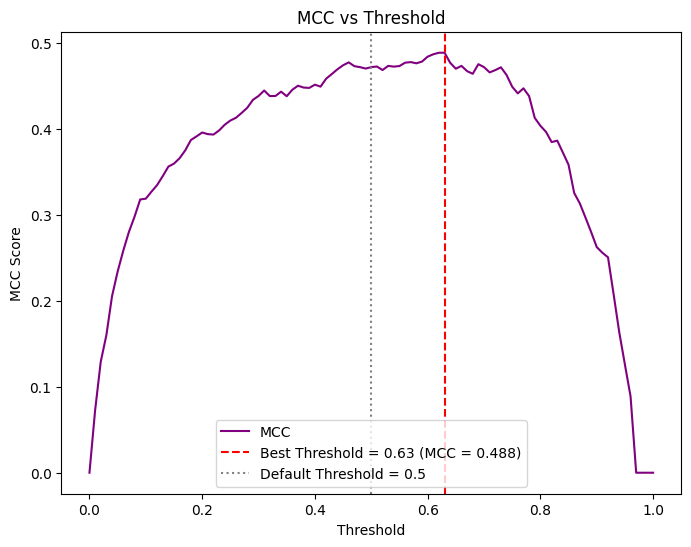

Best threshold: 0.63, Best MCC: 0.488


In [85]:
import numpy as np
from sklearn.metrics import matthews_corrcoef
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.0, 1.01, 0.01)
mcc_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_test, y_pred_t))

best_idx = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(thresholds, mcc_scores, color='purple', label='MCC')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best Threshold = {best_threshold:.2f} (MCC = {best_mcc:.3f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default Threshold = 0.5')
plt.xlabel("Threshold")
plt.ylabel("MCC Score")
plt.title("MCC vs Threshold")
plt.legend()
plt.show()

print(f"Best threshold: {best_threshold:.2f}, Best MCC: {best_mcc:.3f}")

Note — MCC vs Threshold (Exploratory)

Purpose: Check if adjusting threshold improves MCC over the default (0.5).

Observation: Best MCC (0.488) occurs at threshold = 0.63 — marginally better than default (0.471 at 0.5).

Decision: Exploratory only — not used as the final threshold. MCC-optimal threshold assumes equal FN/FP cost, which doesn't match business reality (FN is 30x costlier than FP). Actual deployment threshold is decided next using the cost function, which will land far lower (~0.06) due to this cost asymmetry.

In [86]:
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

y_prob = best_model.predict_proba(X_test)[:, 1]

# Cost values (according to business )
cost_fn = 15000   # missed churner  loss
cost_fp = 500     # unnecessary retention offer cost

thresholds = np.arange(0.0, 1.01, 0.01)
total_costs = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = (fn * cost_fn) + (fp * cost_fp)
    total_costs.append(cost)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_threshold = thresholds[best_idx]
best_cost = total_costs[best_idx]

# Main cost curve
trace0 = go.Scatter(
    x=thresholds,
    y=total_costs,
    mode='lines',
    name='Total Cost',
    line=dict(color='darkred'),
    hovertemplate='Threshold=%{x:.2f}<br>Cost=₹%{y:,.0f}<extra></extra>'
)

# Optimal threshold - green dashed vertical line
optimal_line = go.Scatter(
    x=[best_threshold, best_threshold],
    y=[min(total_costs), max(total_costs)],
    mode='lines',
    name=f'Optimal Threshold = {best_threshold:.2f} (Cost = ₹{best_cost:,.0f})',
    line=dict(color='green', dash='dash')
)

# Star marker at optimal threshold
optimal_star = go.Scatter(
    x=[best_threshold],
    y=[best_cost],
    mode='markers',
    name='Minimum Cost Point',
    marker=dict(
        color='green',
        size=14,
        symbol='star'
    ),
    hovertemplate='Optimal Threshold=%{x:.2f}<br>Min Cost=₹%{y:,.0f}<extra></extra>'
)

# Default threshold - gray dotted vertical line
default_line = go.Scatter(
    x=[0.5, 0.5],
    y=[min(total_costs), max(total_costs)],
    mode='lines',
    name='Default Threshold = 0.5',
    line=dict(color='gray', dash='dot')
)

layout = go.Layout(
    title='Total Business Cost vs Threshold',
    xaxis=dict(title='Threshold'),
    yaxis=dict(title='Total Cost (₹)'),
    width=1200,
    height=600,
    showlegend=True
)

fig = go.Figure(
    data=[trace0, optimal_line, optimal_star, default_line],
    layout=layout
)

fig.show()

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Minimum Total Cost: ₹{best_cost:,.0f}")

# Confusion Matrix
y_pred_optimal = (y_prob >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"\nAt optimal threshold:")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Customers flagged as 'high risk': {tp + fp}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Optimal Threshold: 0.06
Minimum Total Cost: ₹445,000

At optimal threshold:
TP=371, TN=235, FP=800, FN=3
Customers flagged as 'high risk': 1171


Note — Total Business Cost vs Threshold (Cost-Based Optimization)

Purpose: Derive the actual deployment threshold using real business costs (FN = ₹15,000, FP = ₹500), instead of a generic/balanced metric.

Observation: Cost is minimized at threshold = 0.06 (Total Cost = ₹445,000). At this point, FN drops to just 3 (almost all churners caught), while FP rises to 800 — an acceptable trade-off given FN costs ~30x more than FP. 1,171 customers flagged as high-risk.
    
Decision: This is the primary, business-driven threshold — used for all downstream decisions (replaces ROC/MCC-based thresholds).
                                                               
Caveat: Required spend for 1,171 customers (₹585,500) exceeds the actual budget (₹300,000) — addressed next via budget-constrained targeting.

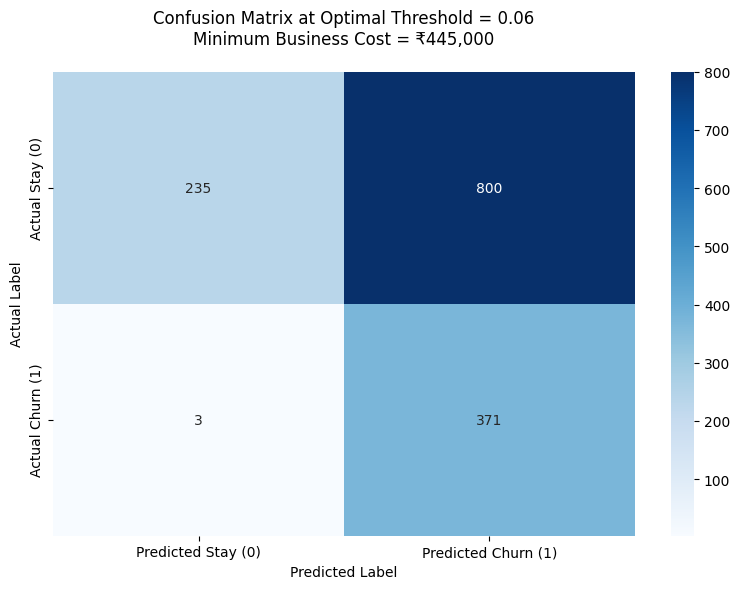

Optimal Threshold: 0.06
Minimum Total Cost: ₹445,000
TP=371, TN=235, FP=800, FN=3
Customers flagged as 'high risk': 1171


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion Matrix values
tn = 235
fp = 800
fn = 3
tp = 371

cm = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'],
    yticklabels=['Actual Stay (0)', 'Actual Churn (1)']
)

plt.title(
    "Confusion Matrix at Optimal Threshold = 0.06\n"
    "Minimum Business Cost = ₹445,000",
    pad=20
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

# Additional business summary
print("Optimal Threshold:", 0.06)
print("Minimum Total Cost: ₹445,000")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Customers flagged as 'high risk': {tp + fp}")

Note — Confusion Matrix at Optimal Threshold (0.06)

Purpose: Visualize the confusion matrix corresponding to the cost-optimal threshold for a clearer, presentable view (vs. raw numbers in Step 7).

Observation: Confirms same result — TP=371, TN=235, FP=800, FN=3, at minimum total cost of ₹445,000.

Decision: This is the reference confusion matrix for the unconstrained (no-budget-limit) scenario — used for comparison against the budget-constrained result (Step 10).

In [88]:
import pandas as pd
import numpy as np

y_prob = best_model.predict_proba(X_test)[:, 1]

# Step 1: DataFrame - actual label + predicted probability
ranking_df = pd.DataFrame({
    'actual': y_test.reset_index(drop=True),
    'churn_probability': y_prob
})

# Step 2: Arranging according to the Probability . 
ranking_df = ranking_df.sort_values(by='churn_probability', ascending=False).reset_index(drop=True)

# Step 3: Top 600 picked (budget-constrained selection)
budget = 300000
cost_per_offer = 500
top_n = budget // cost_per_offer   # 600

top_customers = ranking_df.head(top_n)

# Step 4: New confusion matrix inside 600 customers.
tp = (top_customers['actual'] == 1).sum()   # in those 600 customers genuinely churner
fp = (top_customers['actual'] == 0).sum()   # in those 600 customers genuinely non-churner

# Remaining customers (who didn't get offer)
remaining_customers = ranking_df.iloc[top_n:]
fn = (remaining_customers['actual'] == 1).sum()   # churner,got offer
tn = (remaining_customers['actual'] == 0).sum()   # non-churners , who didnt get offer

print(f"Top {top_n} customers selected (budget-constrained)")
print(f"TP = {tp}  (correctly targeted churners)")
print(f"FP = {fp}  (offer wasted on non-churners)")
print(f"FN = {fn}  (churners missed due to budget limit)")
print(f"TN = {tn}  (correctly not targeted)")

# Actual cost check
actual_spend = top_n * cost_per_offer
total_cost = (fn * 15000) + (fp * 500)
print(f"\nActual spend: ₹{actual_spend:,}")
print(f"Total cost (FN loss + FP waste): ₹{total_cost:,}")

Top 600 customers selected (budget-constrained)
TP = 304  (correctly targeted churners)
FP = 296  (offer wasted on non-churners)
FN = 70  (churners missed due to budget limit)
TN = 739  (correctly not targeted)

Actual spend: ₹300,000
Total cost (FN loss + FP waste): ₹1,198,000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Note — Budget-Constrained Selection (Top 600 by Probability)

Purpose: Apply real budget limit (₹300,000 → 600 customers max) by ranking customers by churn probability instead of using a fixed threshold.

Observation: TP=304, FP=296, FN=70, TN=739. Spend stays within budget (₹300,000), but FN rises sharply (3 → 70) since only the top-ranked 600 can be targeted.

Decision: Total cost rises to ₹1,198,000 — ₹753,000 higher than the unconstrained scenario (₹445,000) — quantifies the real financial impact of the budget cap.

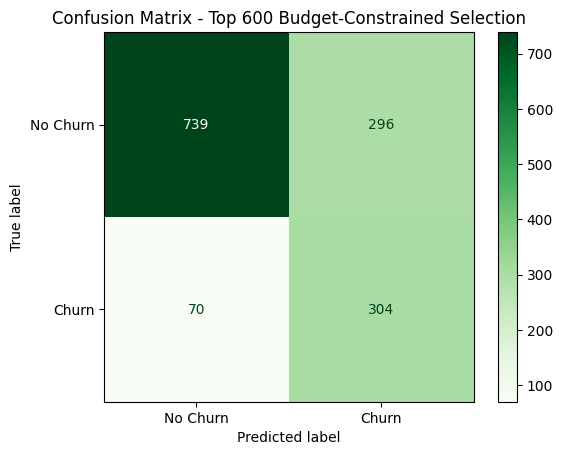

TN=739, FP=296, FN=70, TP=304


In [89]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

cm_budget = np.array([[tn, fp],
                       [fn, tp]])

ConfusionMatrixDisplay(cm_budget, display_labels=['No Churn', 'Churn']).plot(cmap='Greens')
plt.title(f"Confusion Matrix - Top {top_n} Budget-Constrained Selection")
plt.show()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Note — Confusion Matrix: Top 600 Budget-Constrained Selection

Purpose: Visualize the budget-constrained confusion matrix for a clearer, presentable view (vs. raw numbers in Step 9).

Observation: Confirms same result — TN=739, FP=296, FN=70, TP=304.

Decision: This is the final, realistic confusion matrix under actual budget constraints — the one to report to business stakeholders alongside the ₹1,198,000 total cost and ₹753,000 impact of the budget cap.

# Solution Approach & Results

## 1. Threshold Selection Method

Rather than using the default 0.5 or a PR-AUC/F1-based choice, the threshold was derived using a **cost function**:

```python
Total Cost = (FN × 15000) + (FP × 500)
```

This was computed across all possible thresholds (0 to 1), and the threshold minimizing total cost was selected.

---

## 2. Stage 1 — Cost-Optimal Threshold (Unconstrained)

```python
import numpy as np

thresholds = np.arange(0, 1, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    FP = ((y_true == 0) & (y_pred == 1)).sum()
    cost = FN * 15000 + FP * 500
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)
```

**Result:**
```python
Optimal Threshold: 0.06
TP = 371, TN = 235, FP = 800, FN = 3
Customers flagged: 1,171
Required spend: ₹585,500
Total business cost: ₹445,000
```

---

## 3. Stage 2 — Budget-Constrained Targeting (Top-N Ranking)

Since ₹585,500 exceeds the actual ₹300,000 budget, threshold-based selection was replaced with **probability-ranked top-N selection**:

```python
# Budget = ₹300,000 → max affordable customers = 600
ranked = df.sort_values("churn_probability", ascending=False)
selected = ranked.head(600)
```

**Result:**
```python
TP = 304, TN = 739, FP = 296, FN = 70
Actual spend: ₹300,000
Total business cost: ₹1,198,000
```

---

## 4. Final Cost Comparison

| Scenario | Threshold/Selection | Spend | FN | FP | Total Cost |
|---|---|---|---|---|---|
| A — Unconstrained | t = 0.06 | ₹585,500 | 3 | 800 | ₹445,000 |
| B — Budget-constrained | Top 600 by rank | ₹300,000 | 70 | 296 | ₹1,198,000 |

**Extra loss caused by budget cap:**
```python
extra_loss = 1198000 - 445000   # ₹753,000
```
